# AIPI 590 - XAI | Assignment #1
### Assumption Junction
### Han Wang

#### Include the button below. Change the link to the location in your github repository:
#### Example: https://colab.research.google.com/github/duke-aipi-Han/aipi590-XAI/blob/main/assumption-junction/telco-churn-analysis.ipynb


[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/duke-aipi-Han/aipi590-XAI/blob/main/assumption-junction/telco-churn-analysis.ipynb)

In [1]:
# Install the one dependency that is not included in Colab.
%pip install -q pygam==0.12.0

import warnings

# kagglehub checks for optional notebook widgets; progress bars still work without them.
warnings.filterwarnings(
    'ignore',
    message='IProgress not found.*',
    category=Warning
)

import kagglehub as kh
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

from pygam import LogisticGAM, f, s

# Some macOS Accelerate builds emit spurious matmul warnings even when inputs
# and model outputs are finite. Keep other RuntimeWarnings visible.
warnings.filterwarnings(
    'ignore',
    message='(divide by zero|overflow|invalid value) encountered in matmul',
    category=RuntimeWarning
)

Note: you may need to restart the kernel to use updated packages.


In [2]:
# download dataset using kagglehub
# https://www.kaggle.com/datasets/blastchar/telco-customer-churn

path = kh.dataset_download("blastchar/telco-customer-churn")
file = "WA_Fn-UseC_-Telco-Customer-Churn.csv"
full_path = os.path.join(path, file)

df = pd.read_csv(full_path)
print("dataframe loaded from:", full_path)
print(f"Dataframe shape: {df.shape}")

dataframe loaded from: /Users/hanwang/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv
Dataframe shape: (7043, 21)


In [3]:
display(df.head(5))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Task 1:
Exploratory Data Analysis to check Assumptions: Perform an exploratory analysis of the dataset to understand the relationships between different features and the target variable (churn). Use appropriate visualizations and statistical methods to determine whether assumptions about linear, logistic, and GAM models are met. 


### 1.1: Basic EDA of data

In [4]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None

In [5]:
# why is TotalCharges object type? it should be numeric. let's check the unique values
display(df['TotalCharges'].unique())

# is there an empty string in TotalCharges? let's check
display(df[df['TotalCharges'] == ' '])

# Convert TotalCharges to numeric and treat blank values as zero for new customers.
blank_total_charges = df['TotalCharges'].eq(' ').sum()
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
df['TotalCharges'] = df['TotalCharges'].fillna(0)
print(f'Blank TotalCharges values converted to zero: {blank_total_charges}')
print('Check that these rows have zero tenure:')
display(df.loc[df['TotalCharges'].eq(0), ['tenure', 'TotalCharges']].head())

array(['29.85', '1889.5', '108.15', ..., '346.45', '306.6', '6844.5'],
      dtype=object)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,,No


Blank TotalCharges values converted to zero: 11
Check that these rows have zero tenure:


,tenure,TotalCharges
488,0,0.0
753,0,0.0
936,0,0.0
1082,0,0.0
1340,0,0.0


In [6]:
# try to separate out categorical and numerical features by looking at # unique
print(df.nunique())

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64


In [7]:
display(df.describe(include='all'))

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043.000000,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,NaN,2
top,7590-VHVEG,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,NaN,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,NaN,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,2279.734304,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,2266.794470,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,0.000000,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,398.550000,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,1394.550000,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,3786.600000,NaN


In [8]:
y_raw = df['Churn']

# Exclude customerID because it is an identifier. Demographic fields are excluded
# to reduce direct use of sensitive attributes; remaining variables may still be proxies.
drop_cols = ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Churn']
X_raw = df.drop(drop_cols, axis=1)
print('Excluded columns:', drop_cols)
print('These models estimate predictive associations, not causal effects.')

Excluded columns: ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Churn']
These models estimate predictive associations, not causal effects.


In [9]:
# separate continues from categorical variables
continues_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_cols = [col for col in X_raw.columns if col not in continues_cols]

X_continuous = X_raw[continues_cols]
X_categorical = X_raw[categorical_cols]

<Axes: xlabel='Churn', ylabel='count'>

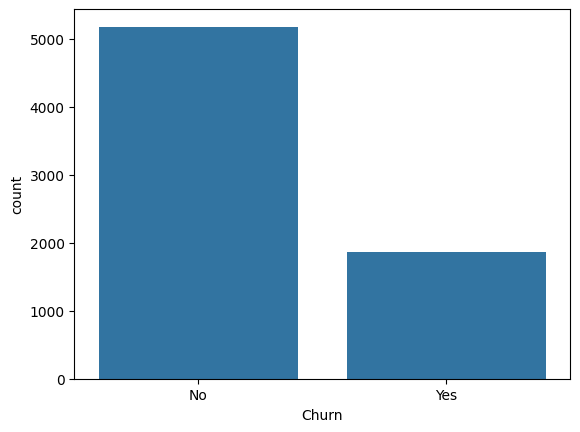

In [10]:
# distribution of response variable is unbalanced, with more "No" than "Yes"; Use statified sampling later.
sns.countplot(x='Churn', data=df)

### 1.2: Linear assumptions

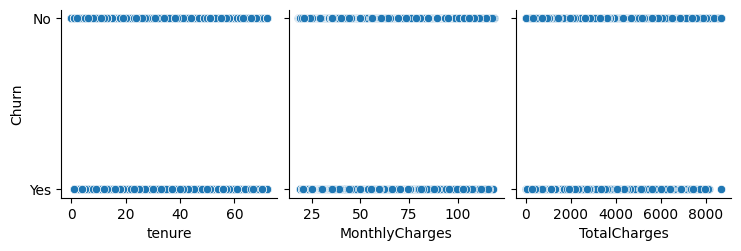

In [11]:
# scatter of each column vs response
sns.pairplot(df, x_vars=X_continuous.columns, y_vars=['Churn'], kind='scatter')

Because the target variable is categorical, difficult to visually see any linearity; Check residuals later

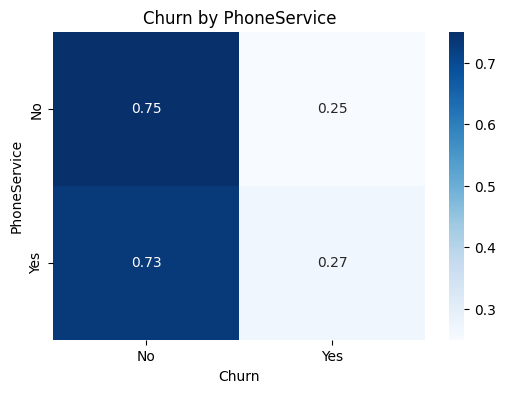

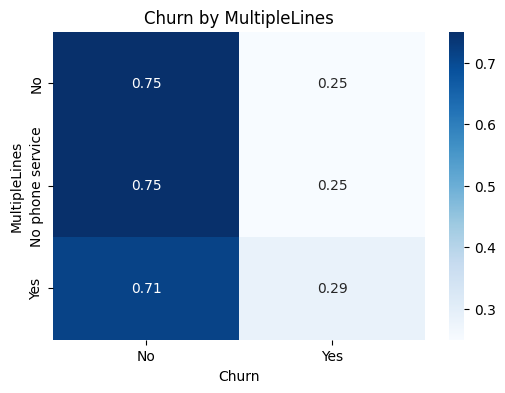

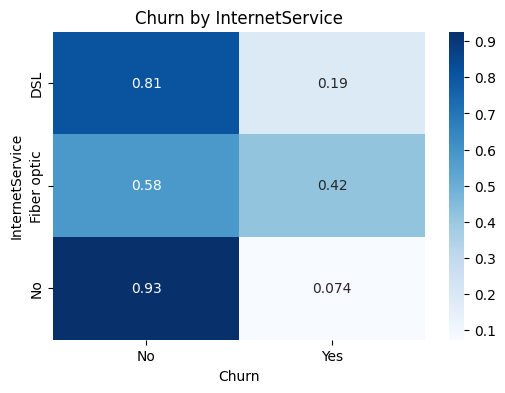

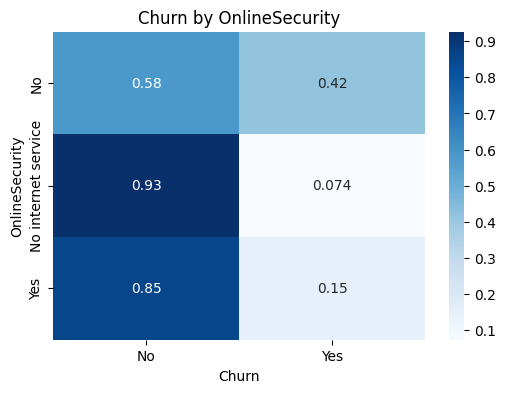

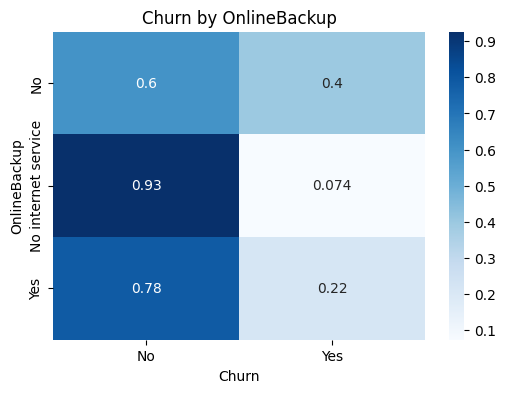

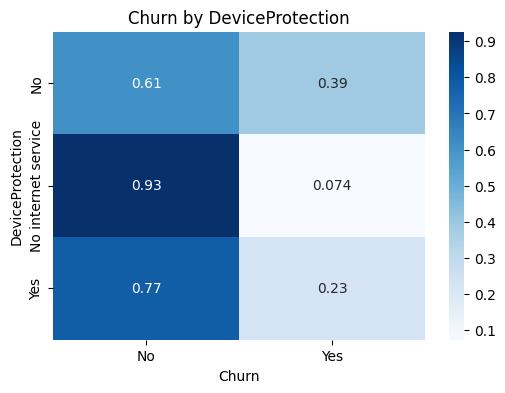

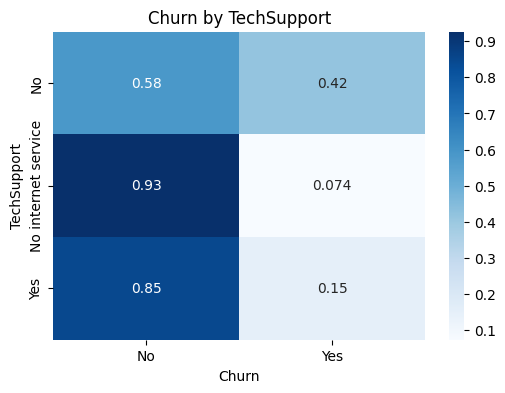

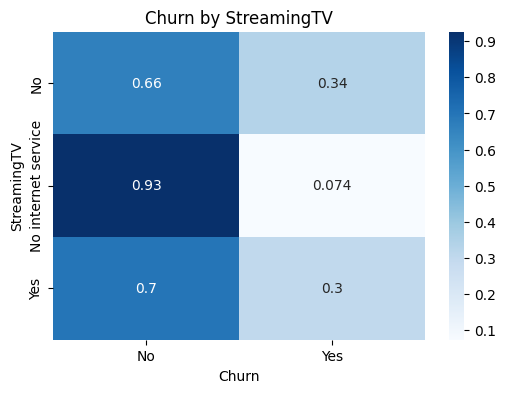

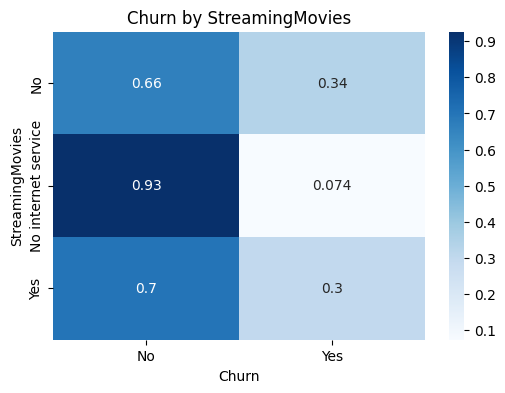

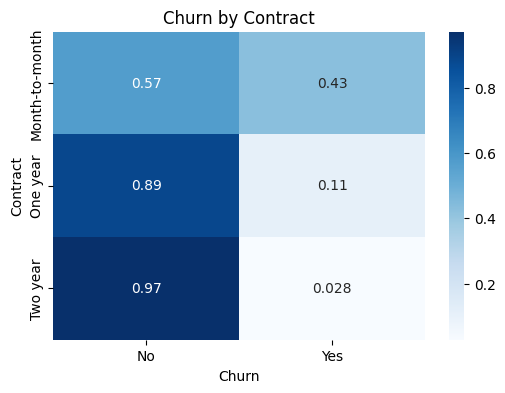

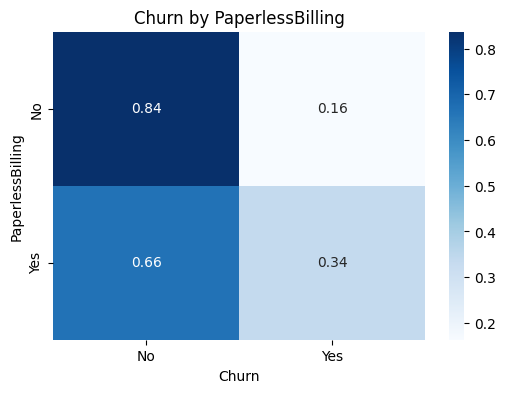

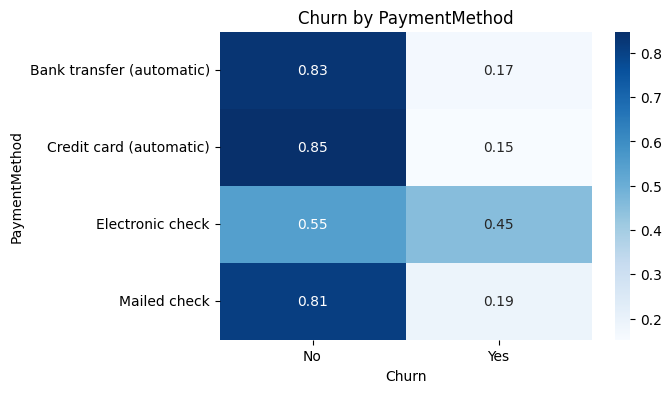

In [12]:
# check categorical predictors; does not require linearity checks.

# display heatmaps of each categorical variable vs response variable
for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.heatmap(pd.crosstab(df[col], df['Churn'], normalize='index'), annot=True, cmap='Blues')
    plt.title(f'Churn by {col}')
    plt.show()



In [13]:
# independence of observations
# in this dataset, each row is a customer, and each customer is independent of each other. So this assumption is satisfied. Also depends on data collection method.

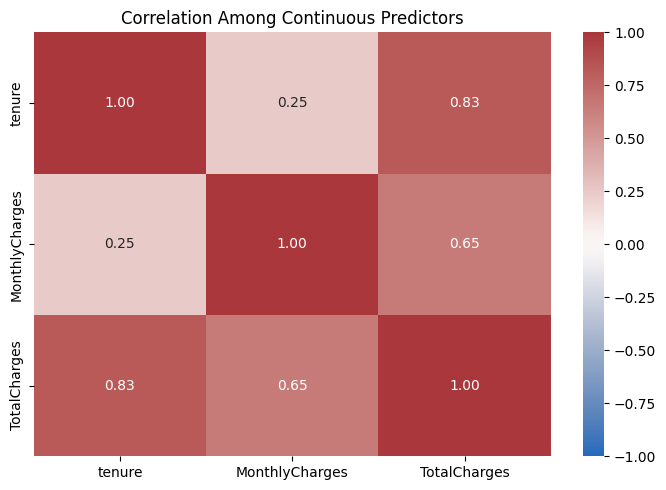

In [14]:
# multicollinearity check
# Check correlations among the continuous predictors.
correlation_matrix = X_continuous.corr()

plt.figure(figsize=(7, 5))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='vlag',
    center=0,
    vmin=-1,
    vmax=1,
    fmt='.2f'
)
plt.title('Correlation Among Continuous Predictors')
plt.tight_layout()
plt.show()

# Strong correlations, especially between tenure and TotalCharges, indicate
# possible multicollinearity and can make individual model effects unstable.

no surprise that longer tenure means more total charges, so those are correlated. Perhaps drop total charges?

### 1.3: GAM assumptions

Unlike linear regression, GAM uses splines so it can handle non-linearity. It still needs independent observations which is there.
There's some target class imbalance.

## Task 2: 
Linear Regression: Treat the churn variable as a continuous variable (e.g., 0 for staying, 1 for churning) and build a linear regression model to predict churn. Interpret the coefficients and assess the model's performance.


In [15]:
# prep data for regression:
# convert y to continuous variable for regression analysis
y = y_raw.map({'No': 0, 'Yes': 1})

# one-hot encode categorical variables
X = pd.get_dummies(X_raw, drop_first=True)

duplicate_columns = X.T.duplicated()
duplicate_features = X.columns[duplicate_columns].tolist()

print("Duplicate features removed:", duplicate_features)

X = X.loc[:, ~duplicate_columns]

Duplicate features removed: ['OnlineSecurity_No internet service', 'OnlineBackup_No internet service', 'DeviceProtection_No internet service', 'TechSupport_No internet service', 'StreamingTV_No internet service', 'StreamingMovies_No internet service']


In [16]:
y.describe()


count    7043.000000
mean        0.265370
std         0.441561
min         0.000000
25%         0.000000
50%         0.000000
75%         1.000000
max         1.000000
Name: Churn, dtype: float64

In [17]:
X.describe(include='all')

,tenure,MonthlyCharges,TotalCharges,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_Yes,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,7043.000000,7043.000000,7043.000000,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,NaN,NaN,NaN,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
top,NaN,NaN,NaN,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False
freq,NaN,NaN,NaN,6361,6361,4072,3947,5517,5024,4614,4621,4999,4336,4311,5570,5348,4171,5521,4678,5431
mean,32.371149,64.761692,2279.734304,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,24.559481,30.090047,2266.794470,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,0.000000,18.250000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,9.000000,35.500000,398.550000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,29.000000,70.350000,1394.550000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,55.000000,89.850000,3786.600000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
# Perform a stratified split so the churn proportion is similar in train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Check for the non-finite values and constant columns that can cause numerical warnings.
print(f'Train shape: {X_train.shape}; Test shape: {X_test.shape}')
print(f'Train churn rate: {y_train.mean():.3f}; Test churn rate: {y_test.mean():.3f}')
print(f'All scaled values are finite: {np.isfinite(X_train_scaled).all()}')
print(f'Zero-variance columns: {(X_train.nunique() <= 1).sum()}')
print(f'Max absolute scaled value: {np.abs(X_train_scaled).max():.2f}')

if not np.isfinite(X_train_scaled).all() or not np.isfinite(X_test_scaled).all():
    raise ValueError('The scaled feature matrices contain non-finite values.')

Train shape: (5634, 20); Test shape: (1409, 20)
Train churn rate: 0.265; Test churn rate: 0.265
All scaled values are finite: True
Zero-variance columns: 0
Max absolute scaled value: 3.01


In [19]:
# copied from template provided
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    print(f"\n{model_name}:")
    print(f"MSE: {mse:.2f}")
    print(f"R2 Score: {r2:.2f}")

    for feature, coef in zip(X.columns, model.coef_):
      print(f"{feature}: {coef:.4f}")

    return model, y_pred

In [20]:
lr_model, lr_pred = evaluate_model(LinearRegression(), X_train_scaled, X_test_scaled, y_train, y_test, "Linear Regression")


Linear Regression:
MSE: 0.14
R2 Score: 0.26
tenure: -0.0347
MonthlyCharges: -0.2218
TotalCharges: -0.1097
PhoneService_Yes: 0.0178
MultipleLines_No phone service: -0.0178
MultipleLines_Yes: 0.0466
InternetService_Fiber optic: 0.1855
InternetService_No: -0.1392
OnlineSecurity_Yes: -0.0079
OnlineBackup_Yes: 0.0075
DeviceProtection_Yes: 0.0170
TechSupport_Yes: -0.0067
StreamingTV_Yes: 0.0623
StreamingMovies_Yes: 0.0635
Contract_One year: -0.0464
Contract_Two year: -0.0360
PaperlessBilling_Yes: 0.0249
PaymentMethod_Credit card (automatic): -0.0006
PaymentMethod_Electronic check: 0.0376
PaymentMethod_Mailed check: 0.0033


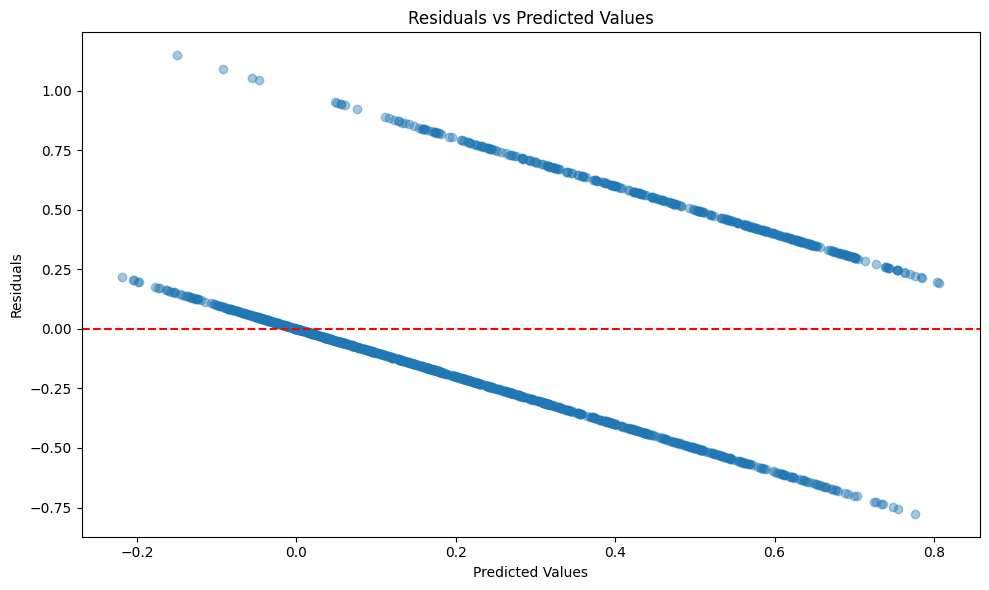

In [21]:
# check for homoscedasticity by plotting residuals vs predicted values
residuals = y_test - lr_pred

plt.figure(figsize=(10, 6))
plt.scatter(lr_pred, residuals, alpha=0.4)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted Values')
plt.tight_layout()
plt.show()

# A roughly constant vertical spread supports homoscedasticity.
# A funnel shape or systematic pattern suggests heteroscedasticity.

# the plot below has a funnel shape, which suggests heteroscedasticity. This violates the assumption of homoscedasticity, which states that the variance of the residuals should be constant across all levels of the independent variables. In this case, the variance of the residuals increases as the predicted values increase, indicating that the model's errors are not evenly distributed. This can lead to inefficient estimates and affect the validity of hypothesis tests.

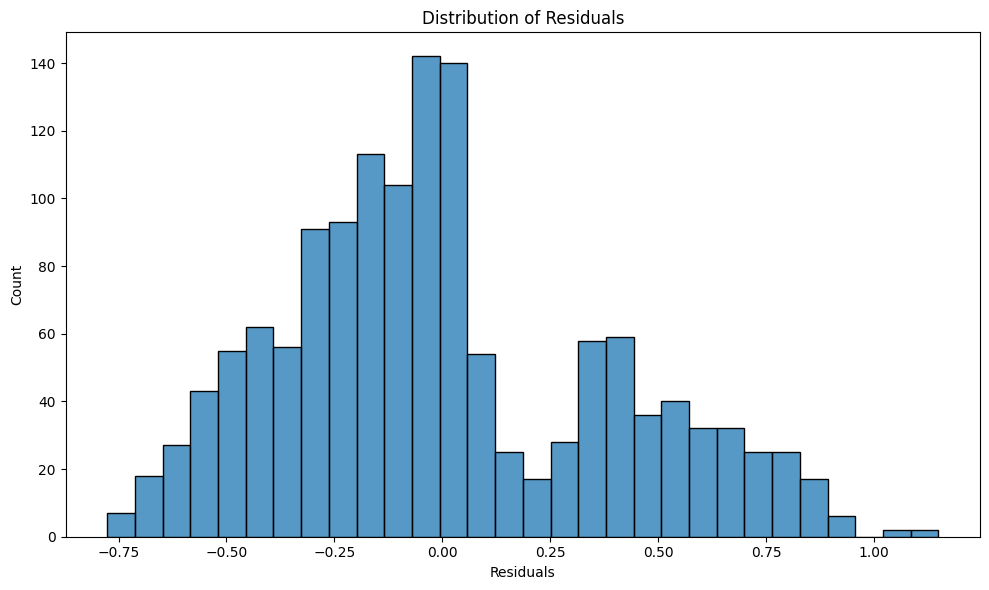

In [22]:
# check for normality of residuals by plotting histogram
plt.figure(figsize=(10, 6))
sns.histplot(residuals, bins=30, kde=False)
plt.xlabel('Residuals')
plt.ylabel('Count')
plt.title('Distribution of Residuals')
plt.tight_layout()
plt.show()

# For a binary target, residuals are not expected to be perfectly normal.
# This histogram is descriptive because linear regression is being used as a baseline.

# historgrams are bimodal with 2 normal looking peaks (which is expected for binary target variable). This indicates that the residuals are not normally distributed, which violates the assumption of normality. Non-normal residuals can affect the validity of hypothesis tests and confidence intervals, leading to unreliable inferences about the model's coefficients.

Looking at the residuals, there are definite signs of heteroscedasticity and the residuals are NOT normally distributed

## Task 3:
Logistic Regression: Treat churn as a binary variable and build a logistic regression model to predict the probability of churn. Interpret the coefficients.


Logistic Regression Results
Accuracy: 0.797
ROC-AUC: 0.841

Classification Report:
              precision    recall  f1-score   support

    No churn       0.84      0.89      0.87      1035
       Churn       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



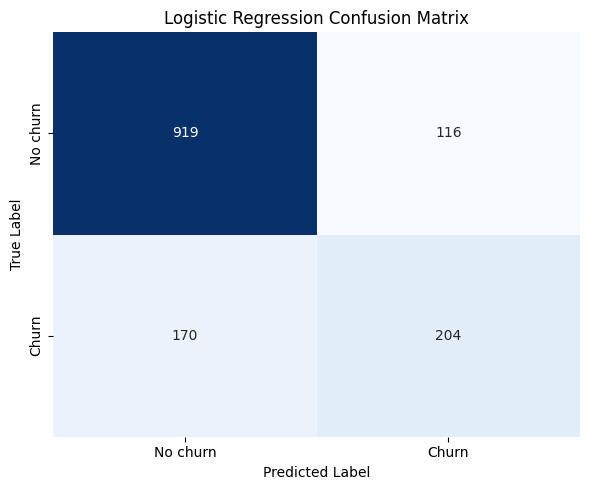

In [23]:
# Fit logistic regression to predict the probability of customer churn.
logistic_model = LogisticRegression(
    max_iter=1000,
    solver='liblinear',
    random_state=42
)
logistic_model.fit(X_train_scaled, y_train)

logistic_pred = logistic_model.predict(X_test_scaled)
logistic_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

# prepare basic results on ROC
print('Logistic Regression Results')
print(f'Accuracy: {accuracy_score(y_test, logistic_pred):.3f}')
print(f'ROC-AUC: {roc_auc_score(y_test, logistic_prob):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, logistic_pred, target_names=['No churn', 'Churn']))

# take a closer look at confusion matrix
confusion = confusion_matrix(y_test, logistic_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(
    confusion,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar=False,
    xticklabels=['No churn', 'Churn'],
    yticklabels=['No churn', 'Churn']
)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Logistic Regression Confusion Matrix')
plt.tight_layout()
plt.show()

## Task 4:
Generalized Additive Model (GAM): Build a GAM to model the non-linear relationships between customer features and churn. Interpret the GAM model. 


Generalized Additive Model Results
Accuracy: 0.799
ROC-AUC: 0.846

Classification Report:
              precision    recall  f1-score   support

    No churn       0.84      0.90      0.87      1035
       Churn       0.65      0.52      0.58       374

    accuracy                           0.80      1409
   macro avg       0.75      0.71      0.72      1409
weighted avg       0.79      0.80      0.79      1409



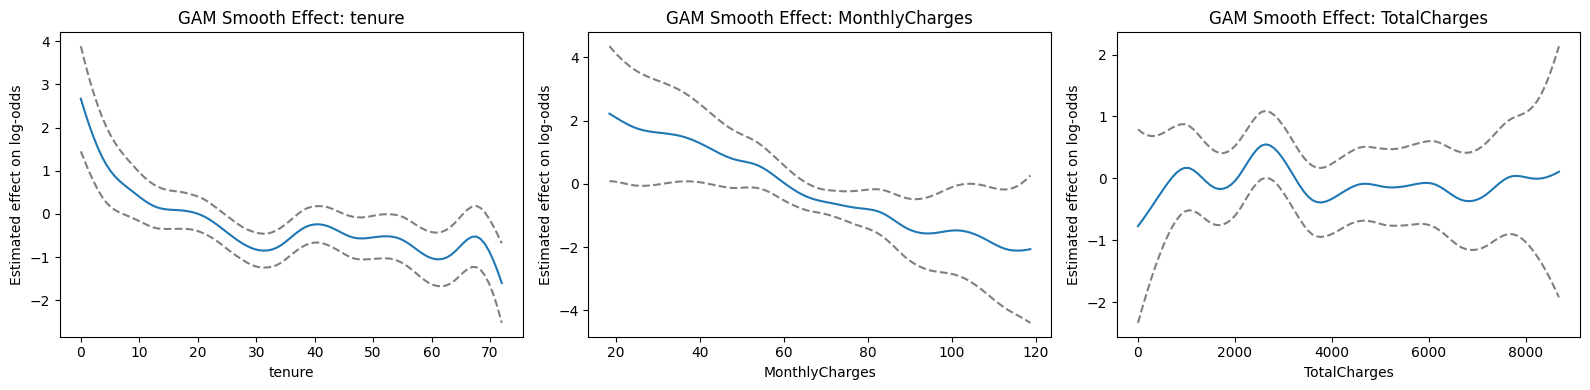

The GAM uses smooth terms for the continuous predictors and factor terms for categorical predictors.
Interpret the smooth-effect plots as changes in log-odds, holding the other predictors constant.


In [24]:

# Build GAM features: smooth terms for continuous variables and factor terms for categories.
X_gam = X_continuous.copy()
for column in X_categorical.columns:
    X_gam[column] = pd.Categorical(X_categorical[column]).codes

# Reuse the same train/test observations as the linear and logistic models.
X_gam_train = X_gam.loc[X_train.index]
X_gam_test = X_gam.loc[X_test.index]

gam_terms = s(0) + s(1) + s(2)
for term_index in range(3, X_gam.shape[1]):
    gam_terms += f(term_index)

# use logistic GAM because churn is binary
gam_model = LogisticGAM(gam_terms).fit(X_gam_train, y_train)
gam_pred = gam_model.predict(X_gam_test)
gam_prob = gam_model.predict_proba(X_gam_test)

print('Generalized Additive Model Results')
print(f'Accuracy: {accuracy_score(y_test, gam_pred):.3f}')
print(f'ROC-AUC: {roc_auc_score(y_test, gam_prob):.3f}')
print('\nClassification Report:')
print(classification_report(y_test, gam_pred, target_names=['No churn', 'Churn']))

# Plot the estimated smooth effects for the continuous predictors.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for term_index, column in enumerate(continues_cols):
    XX = gam_model.generate_X_grid(term=term_index)
    partial_dependence, confidence_intervals = gam_model.partial_dependence(
        term=term_index,
        X=XX,
        width=0.95
    )
    axes[term_index].plot(XX[:, term_index], partial_dependence)
    axes[term_index].plot(
        XX[:, term_index],
        confidence_intervals,
        linestyle='--',
        color='gray'
    )
    axes[term_index].set_xlabel(column)
    axes[term_index].set_ylabel('Estimated effect on log-odds')
    axes[term_index].set_title(f'GAM Smooth Effect: {column}')

plt.tight_layout()
plt.show()

print('The GAM uses smooth terms for the continuous predictors and factor terms for categorical predictors.')
print('Interpret the smooth-effect plots as changes in log-odds, holding the other predictors constant.')

## Task 5:
Model Comparison: Compare the performance and interpretability of the different models you built. Discuss the strengths and weaknesses of each approach and provide recommendations for which model(s) the telecommunications company should use to address their customer churn problem.

,Model,Accuracy,Precision (Churn),Recall (Churn),F1 Score (Churn),ROC-AUC
2,GAM,0.799,0.651,0.524,0.581,0.846
1,Logistic Regression,0.797,0.638,0.545,0.588,0.841
0,Linear Regression,0.791,0.630,0.511,0.564,0.829


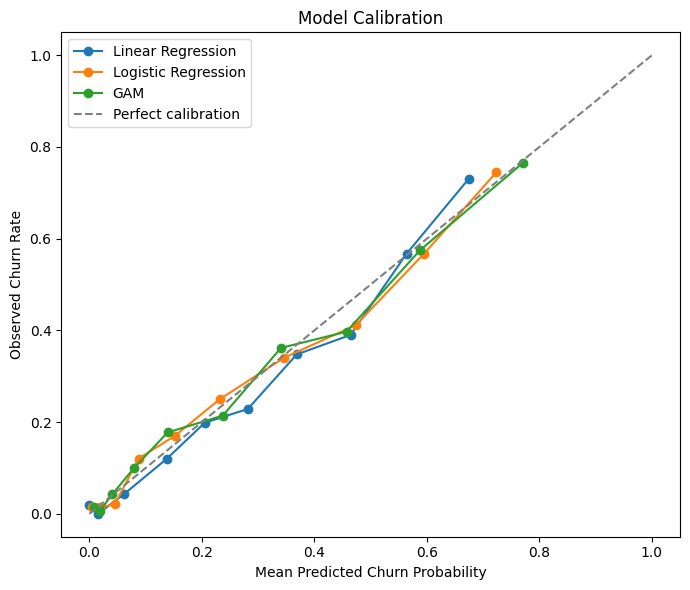

,Model,Threshold,Precision (Churn),Recall (Churn),F1 Score (Churn)
0,Logistic Regression,0.3,0.518,0.762,0.617
1,Logistic Regression,0.4,0.572,0.671,0.617
2,Logistic Regression,0.5,0.638,0.545,0.588
3,Logistic Regression,0.6,0.718,0.388,0.503
4,GAM,0.3,0.528,0.762,0.624
5,GAM,0.4,0.585,0.655,0.618
6,GAM,0.5,0.651,0.524,0.581
7,GAM,0.6,0.735,0.385,0.505


Interpretation:
- Linear regression is included as a baseline, but it is not designed for binary outcomes.
- Logistic regression provides an interpretable linear relationship in log-odds.
- GAM provides interpretable nonlinear smooth effects while retaining probability predictions.
- A lower classification threshold usually identifies more potential churners, increasing recall while reducing precision.
- In this test split, GAM had the highest ROC-AUC.
- The highest default-threshold churn recall was from Logistic Regression (0.545).


In [25]:
from sklearn.calibration import calibration_curve
from sklearn.metrics import f1_score, precision_score, recall_score

# Use the same test observations and threshold for a simple model comparison.
model_predictions = {
    'Linear Regression': ((lr_pred >= 0.5).astype(int), np.clip(lr_pred, 0, 1)),
    'Logistic Regression': (logistic_pred, logistic_prob),
    'GAM': (gam_pred, gam_prob)
}

comparison = []
for model_name, (predictions, probabilities) in model_predictions.items():
    comparison.append({
        'Model': model_name,
        'Accuracy': accuracy_score(y_test, predictions),
        'Precision (Churn)': precision_score(y_test, predictions),
        'Recall (Churn)': recall_score(y_test, predictions),
        'F1 Score (Churn)': f1_score(y_test, predictions),
        'ROC-AUC': roc_auc_score(y_test, probabilities)
    })

comparison = pd.DataFrame(comparison).sort_values('ROC-AUC', ascending=False)
display(comparison.round(3))

# Calibration compares predicted churn probabilities with observed churn rates.
plt.figure(figsize=(7, 6))
for model_name, (_, probabilities) in model_predictions.items():
    observed_rate, mean_probability = calibration_curve(
        y_test,
        probabilities,
        n_bins=10,
        strategy='quantile'
    )
    plt.plot(mean_probability, observed_rate, marker='o', label=model_name)

plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Perfect calibration')
plt.xlabel('Mean Predicted Churn Probability')
plt.ylabel('Observed Churn Rate')
plt.title('Model Calibration')
plt.legend()
plt.tight_layout()
plt.show()

# Check how the classification threshold changes churn recall and precision.
threshold_rows = []
for model_name, probabilities in {
    'Logistic Regression': logistic_prob,
    'GAM': gam_prob
}.items():
    for threshold in [0.3, 0.4, 0.5, 0.6]:
        threshold_predictions = (probabilities >= threshold).astype(int)
        threshold_rows.append({
            'Model': model_name,
            'Threshold': threshold,
            'Precision (Churn)': precision_score(y_test, threshold_predictions),
            'Recall (Churn)': recall_score(y_test, threshold_predictions),
            'F1 Score (Churn)': f1_score(y_test, threshold_predictions)
        })

threshold_comparison = pd.DataFrame(threshold_rows)
display(threshold_comparison.round(3))

best_auc_model = comparison.iloc[0]['Model']
best_recall_row = comparison.loc[comparison['Recall (Churn)'].idxmax()]
print('Interpretation:')
print('- Linear regression is included as a baseline, but it is not designed for binary outcomes.')
print('- Logistic regression provides an interpretable linear relationship in log-odds.')
print('- GAM provides interpretable nonlinear smooth effects while retaining probability predictions.')
print('- A lower classification threshold usually identifies more potential churners, increasing recall while reducing precision.')
print(f'- In this test split, {best_auc_model} had the highest ROC-AUC.')
print(f"- The highest default-threshold churn recall was from {best_recall_row['Model']} ({best_recall_row['Recall (Churn)']:.3f}).")

In [26]:
# Refit logistic regression and GAM after removing the redundant TotalCharges feature.
X_trimmed_raw = X_raw.drop(columns=['TotalCharges'])
X_trimmed = pd.get_dummies(X_trimmed_raw, drop_first=True)

duplicate_columns = X_trimmed.T.duplicated()
X_trimmed = X_trimmed.loc[:, ~duplicate_columns]

X_trimmed_train, X_trimmed_test, y_trimmed_train, y_trimmed_test = train_test_split(
    X_trimmed,
    y,
    test_size=0.2,
    random_state=42
)

trimmed_scaler = StandardScaler()
X_trimmed_train_scaled = trimmed_scaler.fit_transform(X_trimmed_train)
X_trimmed_test_scaled = trimmed_scaler.transform(X_trimmed_test)

trimmed_logistic_model = LogisticRegression(max_iter=1000, random_state=42)
trimmed_logistic_model.fit(X_trimmed_train_scaled, y_trimmed_train)
trimmed_logistic_pred = trimmed_logistic_model.predict(X_trimmed_test_scaled)
trimmed_logistic_prob = trimmed_logistic_model.predict_proba(X_trimmed_test_scaled)[:, 1]

# Prepare the same trimmed features for a GAM.
trimmed_continuous_cols = ['tenure', 'MonthlyCharges']
trimmed_categorical_cols = X_trimmed_raw.columns.difference(trimmed_continuous_cols)
X_trimmed_gam = X_trimmed_raw[trimmed_continuous_cols].copy()

for column in trimmed_categorical_cols:
    X_trimmed_gam[column] = pd.Categorical(X_trimmed_raw[column]).codes

X_trimmed_gam_train = X_trimmed_gam.loc[X_trimmed_train.index]
X_trimmed_gam_test = X_trimmed_gam.loc[X_trimmed_test.index]
trimmed_gam_terms = s(0) + s(1)

for term_index in range(2, X_trimmed_gam.shape[1]):
    trimmed_gam_terms += f(term_index)

trimmed_gam_model = LogisticGAM(trimmed_gam_terms).fit(
    X_trimmed_gam_train,
    y_trimmed_train
)
trimmed_gam_pred = trimmed_gam_model.predict(X_trimmed_gam_test)
trimmed_gam_prob = trimmed_gam_model.predict_proba(X_trimmed_gam_test)

trimmed_comparison = pd.DataFrame([
    {
        'Model': 'Trimmed Logistic Regression',
        'Accuracy': accuracy_score(y_trimmed_test, trimmed_logistic_pred),
        'Precision (Churn)': precision_score(y_trimmed_test, trimmed_logistic_pred),
        'Recall (Churn)': recall_score(y_trimmed_test, trimmed_logistic_pred),
        'F1 Score (Churn)': f1_score(y_trimmed_test, trimmed_logistic_pred),
        'ROC-AUC': roc_auc_score(y_trimmed_test, trimmed_logistic_prob)
    },
    {
        'Model': 'Trimmed GAM',
        'Accuracy': accuracy_score(y_trimmed_test, trimmed_gam_pred),
        'Precision (Churn)': precision_score(y_trimmed_test, trimmed_gam_pred),
        'Recall (Churn)': recall_score(y_trimmed_test, trimmed_gam_pred),
        'F1 Score (Churn)': f1_score(y_trimmed_test, trimmed_gam_pred),
        'ROC-AUC': roc_auc_score(y_trimmed_test, trimmed_gam_prob)
    }
]).sort_values('ROC-AUC', ascending=False)

display(trimmed_comparison.round(3))
print('TotalCharges was removed because it is strongly correlated with tenure.')
print('Compare ROC-AUC, churn recall, and calibration when deciding between the trimmed models.')

,Model,Accuracy,Precision (Churn),Recall (Churn),F1 Score (Churn),ROC-AUC
1,Trimmed GAM,0.809,0.669,0.552,0.605,0.863
0,Trimmed Logistic Regression,0.822,0.688,0.598,0.640,0.860


TotalCharges was removed because it is strongly correlated with tenure.
Compare ROC-AUC, churn recall, and calibration when deciding between the trimmed models.
